In [1]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(246/510)

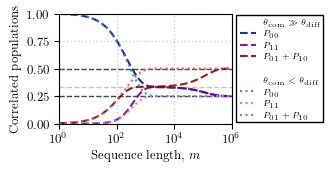

In [ ]:
def pop_sims(ratio, line_id):
    x_min, x_max = 1, 10**6
    m = fh.GTModel()
    model_func = m.model
    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    err_t = 1*10**-1
    theta_diff = np.sqrt(err_t**2/(1+ratio**2))
    theta_com = theta_diff*ratio
    p0 = [theta_com, theta_diff, np.pi/2, 0.0]
    P_fit = model_func(x_fit, *p0).reshape(4, -1)

    return P_fit, x_fit

fig_width = gs.get_fig_width()*246/510
fig_height = 0.85*gs.get_fig_width()/gs.get_phi()*246/510
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
ax = plot_pop_sims(ax, ratio=40.0, line_id=1)
ax = plot_pop_sims(ax, ratio=0.0, line_id=0)
# plt legend to right of the plot
# Shrink current axis by 30%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])

# Put a legend to the right of the current axis
leg = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), framealpha=1.0, frameon=True)
leg.get_frame().set_edgecolor('black')
ax.set_xlabel("Sequence length, $m$")
ax.set_ylabel("Correlated populations")
f_path = "..\\pdf_figure\\f1_pop_analytic.pdf"
plt.subplots_adjust(right=0.7)
fig.savefig(f_path, bbox_inches = "tight")
